# KLIA flight delays: EDA, online-model selection and hyperparameter tuning

**What this notebook does (in order):**
1. Loads your data from Neon (falls back to synthetic demo data if `DATABASE_URL` is not set)
2. Explores it
3. Compares online-learning candidates with **prequential scoring** (predict before learning — no leakage)
4. Tunes the winner's hyperparameters with **Optuna**
5. Logs every experiment to **MLflow** (run `mlflow ui` in the project folder to browse results)
6. Saves the best params to `artifacts/model_choice.json` for the update job

**Demo data warning:** if `DATABASE_URL` is not in `.env`, the notebook runs on synthetic data and does NOT save a model choice. Connect your Neon database and re-run to get a real result.

In [3]:
import os, time, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.grid": True, "grid.alpha": .25})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)

# Load .env (same logic as klia/config.py)
env_file = ROOT / ".env"
if env_file.exists():
    for line in env_file.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        k, _, v = line.partition("=")
        os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))

from klia.config import load_config, database_url, artifacts_dir
from klia.etl.validate import clean
from klia.features.state import FeatureState
from klia.pipeline import feature_stream
from klia.model.online import OnlineClassifier, prequential, best_threshold
from river import drift
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

cfg = load_config()

# MLflow: SQLite backend (required by MLflow 3+; file-store is deprecated)
MLFLOW_DB = ROOT / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB}")
mlflow.set_experiment("klia-flight-delay")
print(f"MLflow tracking: {MLFLOW_DB}")
print("Browse results: mlflow ui --backend-store-uri sqlite:///mlflow.db   (open http://127.0.0.1:5000)")

/mnt/c/Users/owner/Downloads/klia-mlops/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/10/02 19:50:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/02 19:50:37 INFO mlflow.store.db.utils: Updating database tables
2026/10/02 19:50:57 INFO mlflow.tracking.fluent: Experiment with name 'klia-flight-delay' does not exist. Creating a new experiment.


MLflow tracking: /mnt/c/Users/owner/Downloads/klia-mlops/mlflow.db
Browse results: mlflow ui --backend-store-uri sqlite:///mlflow.db   (open http://127.0.0.1:5000)


## 1. Load data

In [4]:
url = database_url()
if url:
    from sqlalchemy import create_engine
    raw = pd.read_sql(
        f"SELECT * FROM {cfg['data']['table']} WHERE actual_departure IS NOT NULL ORDER BY id",
        create_engine(url)
    )
    SOURCE = "Neon"
else:
    from klia.demo import make
    raw = make(20000)
    SOURCE = "DEMO (synthetic)"

print(f"source: {SOURCE} | rows: {len(raw):,} | columns: {list(raw.columns)}")
raw.head()

source: Neon | rows: 80,770 | columns: ['id', 'date', 'scheduled_departure', 'actual_departure', 'flight_number', 'destination', 'aircraft', 'airline', 'day_of_week', 'imported_at', 'temperature_2m', 'precipitation', 'wind_speed_10m', 'wind_speed_120m', 'wind_direction_10m', 'wind_direction_120m', 'wind_direction_180m', 'wind_gusts_10m', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'weather_updated_at']


,id,date,scheduled_departure,actual_departure,flight_number,destination,aircraft,airline,day_of_week,imported_at,...,wind_speed_120m,wind_direction_10m,wind_direction_120m,wind_direction_180m,wind_gusts_10m,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,weather_updated_at
0,1,2026-01-17,09:05:00,09:38:00,AK642,Da Nang,A320,AirAsia (WeAreAllChampions Livery),Saturday,2026-05-01 08:21:29.600208,...,NaN,72.0,NaN,NaN,13.0,98.0,2.0,2.0,98.0,2026-05-04 19:55:30.872569
1,2,2026-01-17,09:05:00,09:18:00,AK5136,Kota Kinabalu,A320,AirAsia,Saturday,2026-05-01 08:21:29.600208,...,NaN,72.0,NaN,NaN,13.0,98.0,2.0,2.0,98.0,2026-05-04 19:55:30.872569
2,3,2026-01-17,09:05:00,09:42:00,D7320,Chengdu,A333,AirAsia X,Saturday,2026-05-01 08:21:29.600208,...,NaN,72.0,NaN,NaN,13.0,98.0,2.0,2.0,98.0,2026-05-04 19:55:30.872569
3,4,2026-01-17,09:05:00,09:27:00,QZ321,Surabaya,A320,AirAsia,Saturday,2026-05-01 08:21:29.600208,...,NaN,72.0,NaN,NaN,13.0,98.0,2.0,2.0,98.0,2026-05-04 19:55:30.872569
4,5,2026-01-17,09:05:00,09:25:00,MH174,Mumbai,B738,Malaysia Airlines,Saturday,2026-05-01 08:21:29.600208,...,NaN,72.0,NaN,NaN,13.0,98.0,2.0,2.0,98.0,2026-05-04 19:55:30.872569


## 2. Data quality

In [5]:
ok, bad = clean(raw, cfg)
print(f"accepted {len(ok):,} | rejected {len(bad):,} ({len(bad)/max(len(raw),1):.2%})")
if len(bad):
    display(bad["reason"].value_counts().to_frame("rows"))
print("date range:", ok.sched_dt.min(), "->", ok.sched_dt.max())
print(f"delay rate (>= {cfg['data']['delay_threshold_minutes']} min): {ok.is_delayed.mean():.1%}")
ok[["delay_min"]].describe().T

accepted 80,758 | rejected 12 (0.01%)


,rows
reason,
implausible delay,12


date range: 2026-01-17 09:05:00 -> 2026-07-31 20:25:00
delay rate (>= 15 min): 61.3%


,count,mean,std,min,25%,50%,75%,max
delay_min,80758.0,27.689083,37.438109,-173.0,10.0,18.0,31.0,1335.0


## 3. Exploration

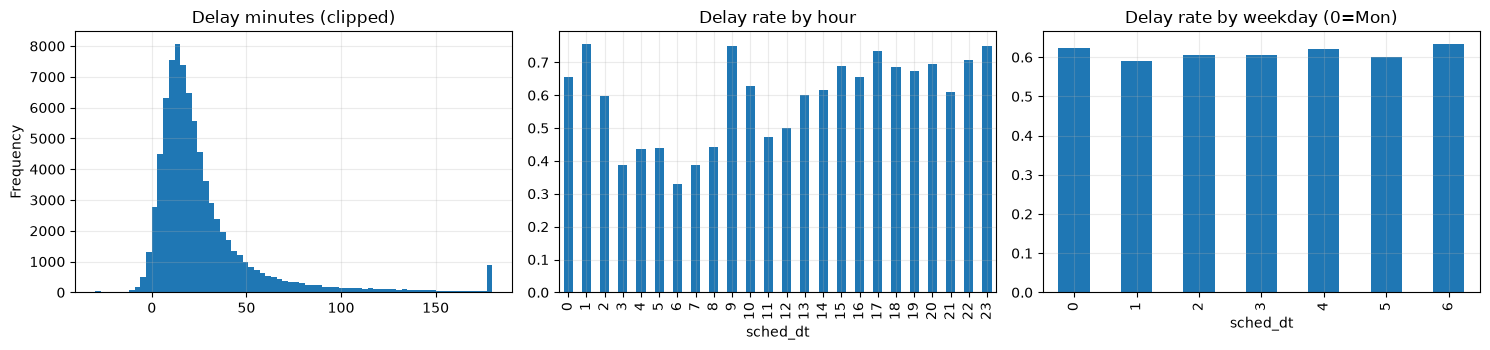

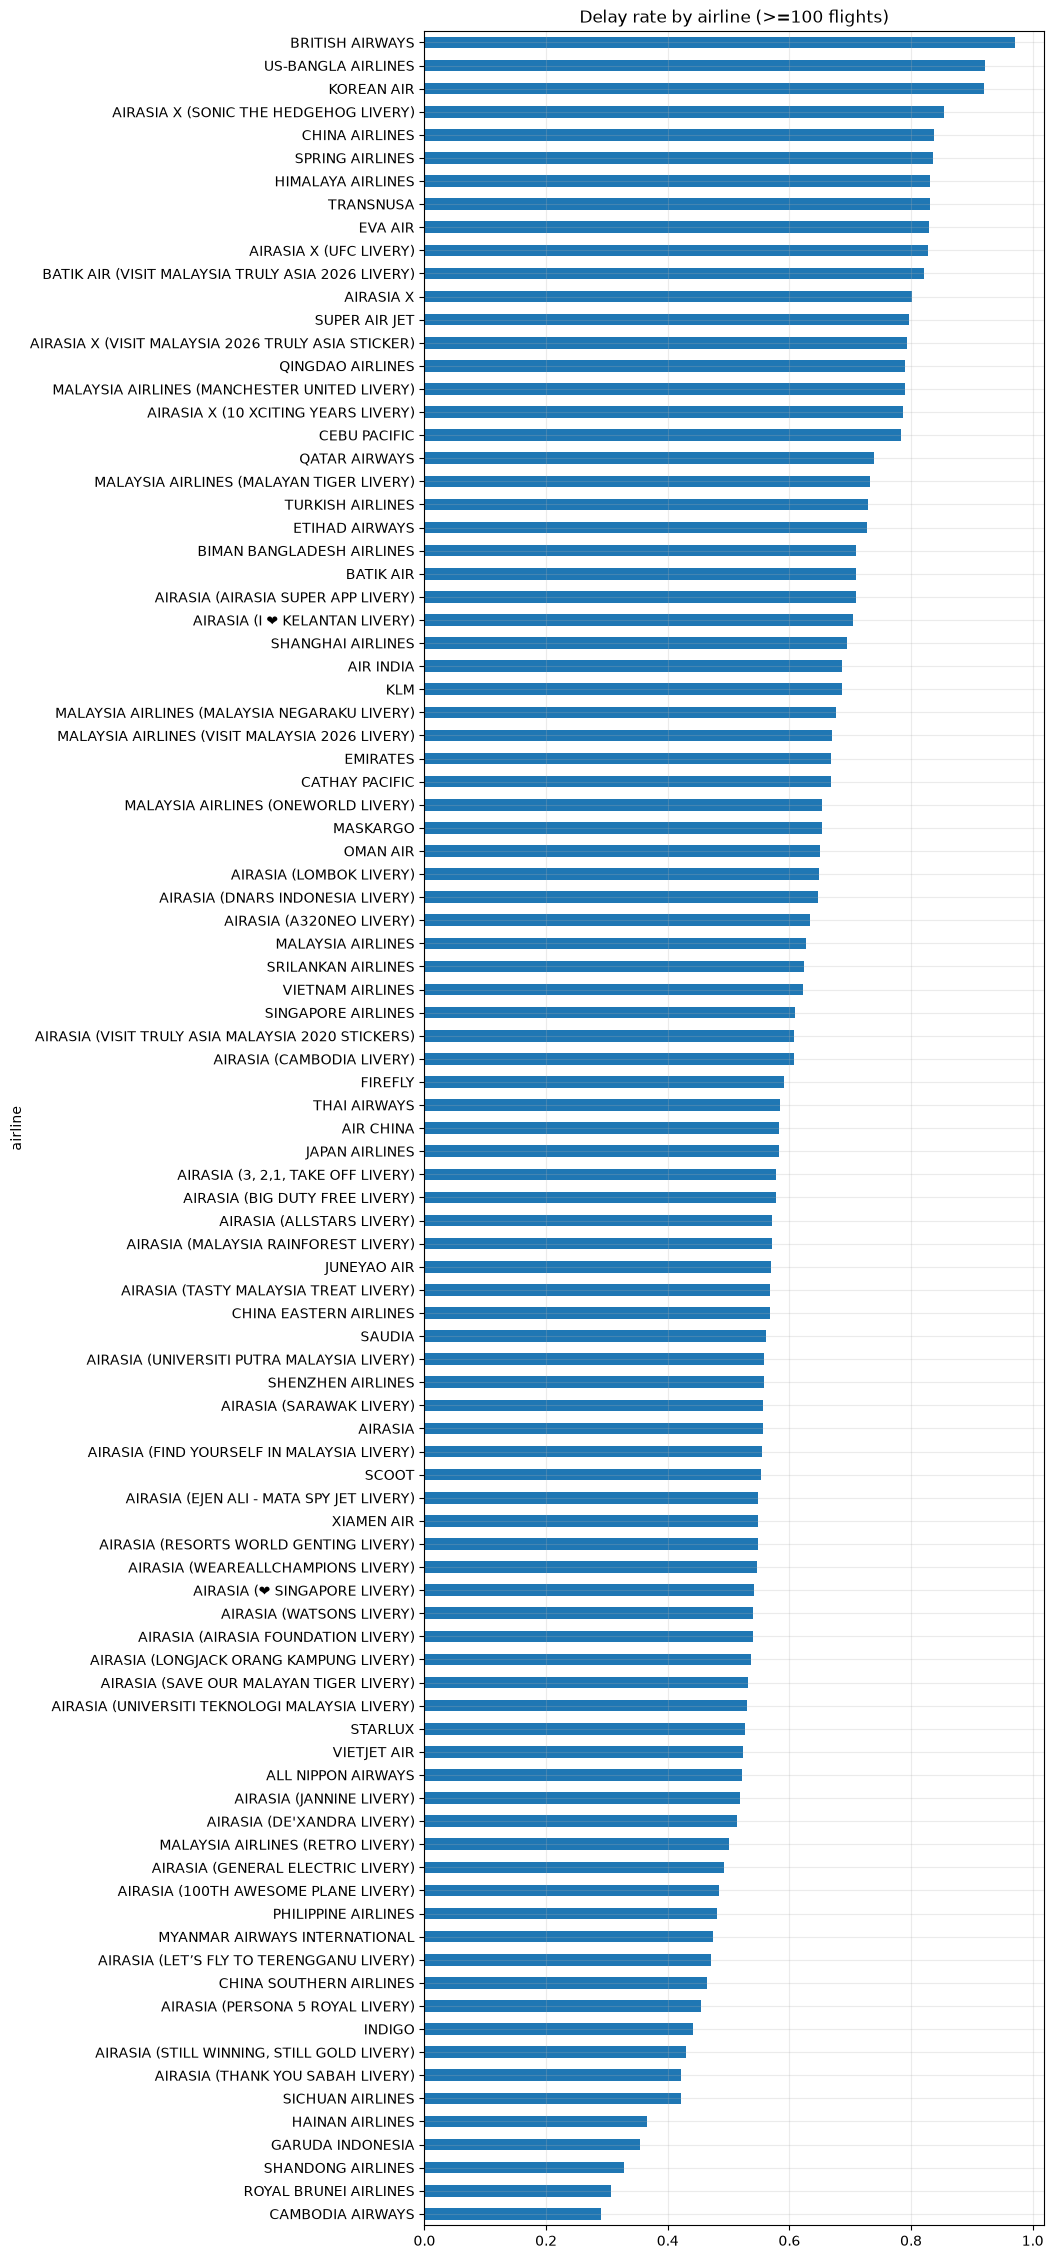

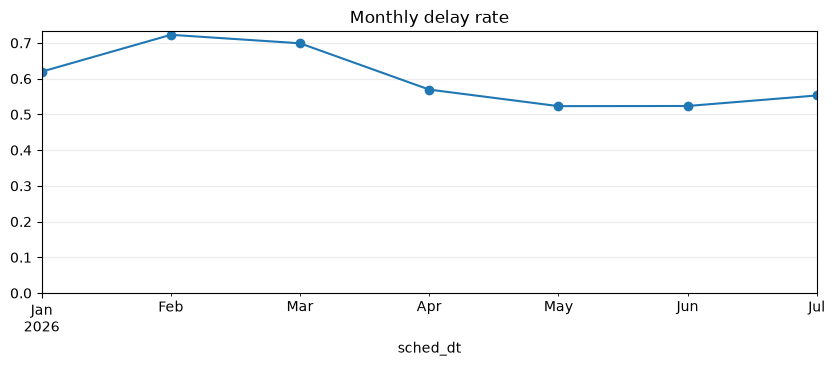

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ok.delay_min.clip(-30, 180).plot.hist(bins=70, ax=ax[0], title="Delay minutes (clipped)")
ok.groupby(ok.sched_dt.dt.hour).is_delayed.mean().plot.bar(ax=ax[1], title="Delay rate by hour")
ok.groupby(ok.sched_dt.dt.dayofweek).is_delayed.mean().plot.bar(ax=ax[2], title="Delay rate by weekday (0=Mon)")
plt.tight_layout(); plt.show()

top = ok.groupby("airline").is_delayed.agg(["mean","count"]).query("count>=100").sort_values("mean")
top["mean"].plot.barh(figsize=(8, max(3, .3*len(top))), title="Delay rate by airline (>=100 flights)"); plt.show()

monthly = ok.set_index("sched_dt").is_delayed.resample("MS").agg(["mean","count"])
fig, a = plt.subplots(figsize=(10, 3.4))
monthly["mean"].plot(ax=a, marker="o", title="Monthly delay rate")
a.set_ylim(0, None); plt.show()

## 4. Features

80,758 rows x 23 features  (17.3s)
features: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_public_holiday', 'is_holiday_eve', 'airline_rate', 'airline_rate_ewm', 'airline_prev3', 'airline_hour_rate', 'destination_rate', 'route_rate', 'route_hour_rate', 'aircraft_rate', 'route_rate_7d', 'route_rate_30d', 'flights_per_hour', 'congestion_x_airline_rate', 'wind_gusts_10m', 'precipitation', 'cloud_cover_mid', 'heavy_weather']


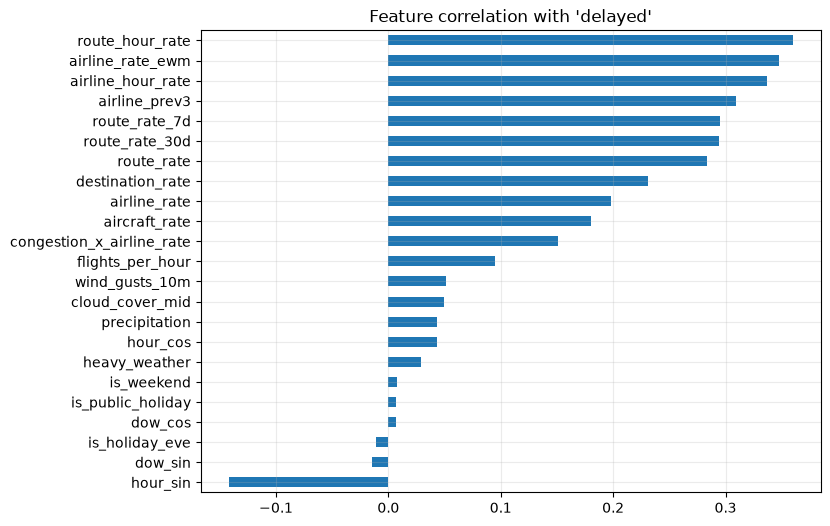

In [7]:
state = FeatureState(cfg)
t0 = time.time()
X, y = feature_stream(ok, state)
y = np.array(y)
print(f"{len(X):,} rows x {len(X[0])} features  ({time.time()-t0:.1f}s)")
print("features:", list(X[0]))

Xdf = pd.DataFrame(X)
corr = Xdf.assign(y=y).corr()["y"].drop("y").sort_values()
corr.plot.barh(figsize=(8, 6), title="Feature correlation with 'delayed'"); plt.show()

## 5. Compare online-model candidates (MLflow: experiment *klia-flight-delay*, run *candidate_comparison*)

All candidates learn **one flight at a time**. Scores are computed with test-then-train (predict before learning),
so every number is out-of-sample in time order, exactly as in production.

In [8]:
CANDIDATES = {
    "baseline: airline rate":       None,
    "logreg":                        {"name": "logreg", "params": {}},
    "hat":                           {"name": "hat",    "params": {}},
    "arf (5t d8)":                   {"name": "arf",    "params": {"n_models": 5,  "max_depth": 8,  "grace_period": 300}},
    "arf (10t d6)":                  {"name": "arf",    "params": {"n_models": 10, "max_depth": 6,  "grace_period": 300}},
    "arf (10t d8)":                  {"name": "arf",    "params": {"n_models": 10, "max_depth": 8,  "grace_period": 300}},
}
WARM = min(1000, len(y) // 10)
MAX_MB, MAX_MS = 15, 3        # free-tier budget: bundle <= 15 MB, <= 3 ms/row

results, probs = [], {}

with mlflow.start_run(run_name="candidate_comparison"):
    mlflow.log_params({"rows": len(y), "warmup": WARM, "source": SOURCE})

    for label, spec in CANDIDATES.items():
        if spec is None:
            p = Xdf["airline_rate"].values; secs = 0.0; mb = 0.0
        else:
            import gzip, pickle
            m = OnlineClassifier(spec["name"], spec["params"])
            t0 = time.time()
            p, _ = prequential(m, X, y.tolist(), warmup=WARM,
                               detector=drift.ADWIN(delta=0.002), fallback=state.base_rate)
            secs = time.time() - t0
            mb = len(gzip.compress(pickle.dumps(m))) / 1e6

        probs[label] = p
        s, yy = p[WARM:], y[WARM:]
        thr, f1 = best_threshold(s, yy)
        auc = roc_auc_score(yy, s)
        ll  = log_loss(yy, np.clip(s, 1e-6, 1-1e-6))
        bs  = brier_score_loss(yy, s)
        ms  = 1000 * secs / max(len(y), 1)
        eligible = spec is not None and mb <= MAX_MB and ms <= MAX_MS

        results.append({"model": label, "AUC": auc, "logloss": ll, "brier": bs,
                        "best_F1": f1, "ms_per_row": ms, "bundle_MB": mb,
                        "eligible": eligible, "spec": spec})

        with mlflow.start_run(run_name=label, nested=True):
            mlflow.log_params({"model": spec["name"] if spec else "baseline",
                               "params": str(spec["params"]) if spec else "{}"})
            mlflow.log_metrics({"auc": round(auc,4), "logloss": round(ll,4),
                                "brier": round(bs,4), "f1": round(f1,4),
                                "ms_per_row": round(ms,3), "bundle_mb": round(mb,2)})
        print(f"  {label:22s}  AUC {auc:.4f}  {'OK' if eligible else 'skip (over budget)'}")

res = pd.DataFrame(results)
res.drop(columns="spec").round(4).sort_values("AUC", ascending=False).reset_index(drop=True)

  baseline: airline rate  AUC 0.6195  skip (over budget)
  logreg                  AUC 0.7781  OK
  hat                     AUC 0.6979  OK
  arf (5t d8)             AUC 0.7510  OK
  arf (10t d6)            AUC 0.7580  OK
  arf (10t d8)            AUC 0.7609  OK


,model,AUC,logloss,brier,best_F1,ms_per_row,bundle_MB,eligible
0,logreg,0.7781,0.5494,0.1852,0.7898,0.1041,0.0017,True
1,arf (10t d8),0.7609,0.5648,0.1916,0.7842,2.1648,14.4790,True
2,arf (10t d6),0.7580,0.5688,0.1932,0.7832,2.0749,5.2416,True
3,arf (5t d8),0.7510,0.5726,0.1949,0.7800,1.2482,5.4702,True
4,hat,0.6979,1.4050,0.2754,0.7542,0.8879,0.8920,True
5,baseline: airline rate,0.6195,0.6522,0.2304,0.7591,0.0000,0.0000,False


In [9]:
# Batch LightGBM reference (trained once on first 70%, cannot update incrementally)
try:
    import lightgbm as lgb
    k = int(len(y) * .7)
    g = lgb.LGBMClassifier(n_estimators=300, learning_rate=.05, verbose=-1).fit(Xdf[:k], y[:k])
    ref = roc_auc_score(y[k:], g.predict_proba(Xdf[k:])[:,1])
    print(f"batch LightGBM (last 30%): AUC {ref:.4f}  [reference only — cannot do online learning]")
    for label, p in probs.items():
        print(f"  {label:26s} AUC on same last 30%: {roc_auc_score(y[k:], p[k:]):.4f}")
except ImportError:
    print("lightgbm not installed, skipping reference point")

batch LightGBM (last 30%): AUC 0.7417  [reference only — cannot do online learning]
  baseline: airline rate     AUC on same last 30%: 0.6380
  logreg                     AUC on same last 30%: 0.7721
  hat                        AUC on same last 30%: 0.6966
  arf (5t d8)                AUC on same last 30%: 0.7406
  arf (10t d6)               AUC on same last 30%: 0.7570
  arf (10t d8)               AUC on same last 30%: 0.7566


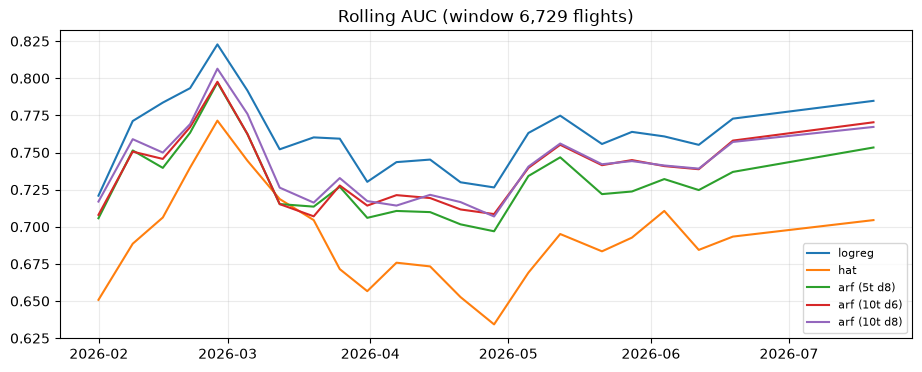

In [10]:
# Rolling AUC: does the model keep up as data distribution shifts?
fig, a = plt.subplots(figsize=(11, 4))
win = max(1500, len(y) // 12)
for label, p in probs.items():
    if label.startswith("baseline"): continue
    pts = [(ok.sched_dt.iloc[i-1], roc_auc_score(y[i-win:i], p[i-win:i]))
           for i in range(WARM+win, len(y), win//2) if y[i-win:i].min() != y[i-win:i].max()]
    if pts: a.plot(*zip(*pts), label=label)
a.set_title(f"Rolling AUC (window {win:,} flights)"); a.legend(fontsize=8); plt.show()

## 6. Optuna hyperparameter tuning (MLflow: run *optuna_tuning*)

Tunes only the **best eligible model type** from section 5. Each Optuna trial is logged as a nested MLflow run.
50 trials takes 2–5 minutes for ARF, under a minute for logreg/HAT.

In [11]:
elig = res[res.eligible]
if elig.empty:
    raise RuntimeError("no eligible model — raise MAX_MB or MAX_MS limits above")

best_row = elig.loc[elig.AUC.idxmax()]
BEST_TYPE = best_row.spec["name"]
print(f"tuning model type: {BEST_TYPE}  (candidate AUC {best_row.AUC:.4f})")

# Parameter search spaces per model type
def suggest(trial: optuna.Trial, name: str) -> dict:
    if name == "logreg":
        return {"lr": trial.suggest_float("lr", 1e-4, 0.5, log=True),
                "l2": trial.suggest_float("l2", 1e-6, 0.1, log=True)}
    if name == "hat":
        return {"grace_period": trial.suggest_int("grace_period", 50, 500, step=50),
                "delta":        trial.suggest_float("delta", 1e-8, 0.1, log=True)}
    if name == "arf":
        return {"n_models":     trial.suggest_int("n_models", 3, 15),
                "max_depth":    trial.suggest_int("max_depth", 4, 12),
                "grace_period": trial.suggest_int("grace_period", 50, 500, step=50),
                "lambda_value": trial.suggest_float("lambda_value", 1, 10)}
    raise ValueError(name)

N_TRIALS = 50

with mlflow.start_run(run_name="optuna_tuning") as parent_run:
    mlflow.log_params({"model_type": BEST_TYPE, "n_trials": N_TRIALS, "warmup": WARM})

    def objective(trial: optuna.Trial) -> float:
        params = suggest(trial, BEST_TYPE)
        m = OnlineClassifier(BEST_TYPE, params)
        p, _ = prequential(m, X, y.tolist(), warmup=WARM, fallback=state.base_rate)
        auc = roc_auc_score(y[WARM:], p[WARM:])

        import gzip, pickle, time as _time
        t1 = _time.time()
        mb = len(gzip.compress(pickle.dumps(m))) / 1e6

        with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
            mlflow.log_params({**params, "trial": trial.number})
            mlflow.log_metrics({"auc": round(auc, 4), "bundle_mb": round(mb, 2)})

        # Prune bundles over budget (Optuna handles the exception)
        if mb > MAX_MB:
            raise optuna.TrialPruned()
        return auc

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    best = study.best_trial
    mlflow.log_params({f"best_{k}": v for k, v in best.params.items()})
    mlflow.log_metric("best_auc", round(best.value, 4))
    print(f"\nbest AUC:  {best.value:.4f}")
    print(f"best params: {best.params}")

tuning model type: logreg  (candidate AUC 0.7781)


Best trial: 43. Best value: 0.779656: 100%|██████████| 50/50 [07:46<00:00,  9.33s/it]



best AUC:  0.7797
best params: {'lr': 0.0069701063136019805, 'l2': 0.02640779042309513}


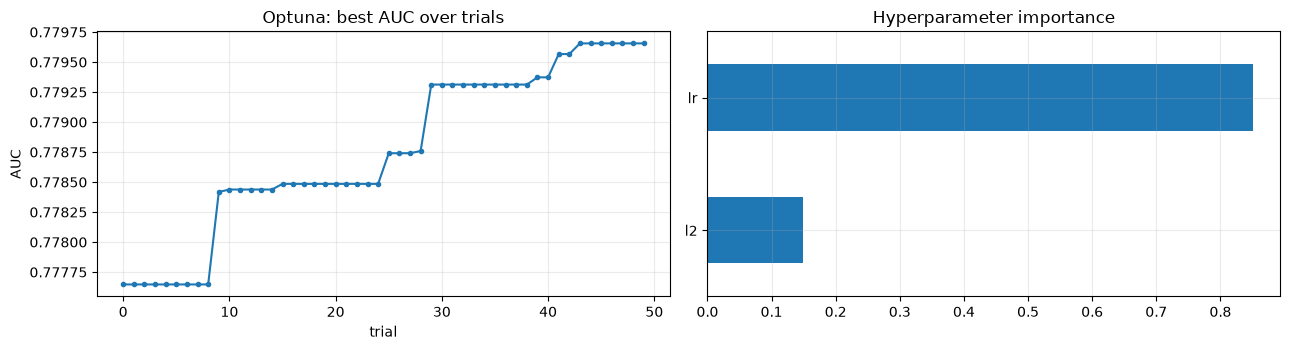


All trials (sorted by AUC):


,number,value,params_lr,params_l2
43,43,0.7797,0.0070,0.0264
41,41,0.7796,0.0058,0.0351
44,44,0.7796,0.0063,0.0176
42,42,0.7795,0.0065,0.0157
39,39,0.7794,0.0061,0.0568
29,29,0.7793,0.0049,0.0152
36,36,0.7793,0.0068,0.0633
33,33,0.7790,0.0051,0.0061
38,38,0.7789,0.0057,0.0854
28,28,0.7788,0.0057,0.0011


In [12]:
# Visualise tuning progress
vals = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.6))
a1.plot(best_so_far, marker=".", label="best AUC so far")
a1.set_xlabel("trial"); a1.set_ylabel("AUC"); a1.set_title("Optuna: best AUC over trials")

imp = optuna.importance.get_param_importances(study)
pd.Series(imp).sort_values().plot.barh(ax=a2, title="Hyperparameter importance")
plt.tight_layout(); plt.show()
print("\nAll trials (sorted by AUC):")
cols = ["number","value"] + ["params_"+k for k in best.params]
display(study.trials_dataframe().sort_values("value", ascending=False)[cols].head(10).round(4))

## 7. Save best params and view in MLflow

In [13]:
if SOURCE.startswith("DEMO"):
    print("DEMO data — NOT saving. Connect DATABASE_URL and re-run.")
else:
    choice = {
        "name":       BEST_TYPE,
        "params":     best.params,
        "auc":        round(float(best.value), 4),
        "rows":       int(len(y)),
        "n_trials":   N_TRIALS,
        "chosen_by":  "notebooks/01_model_selection_eda.ipynb",
    }
    out = artifacts_dir() / "model_choice.json"
    out.write_text(json.dumps(choice, indent=2))
    print("saved", out)
    print(json.dumps(choice, indent=2))

print("\n--- Next steps ---")
print("1. Run:  python -m klia.jobs.update --bootstrap")
print("2. Then: uvicorn klia.api.app:app --port 8000")
print("3. Browse MLflow: mlflow ui --backend-store-uri sqlite:///mlflow.db")

saved /mnt/c/Users/owner/Downloads/klia-mlops/artifacts/model_choice.json
{
  "name": "logreg",
  "params": {
    "lr": 0.0069701063136019805,
    "l2": 0.02640779042309513
  },
  "auc": 0.7797,
  "rows": 80758,
  "n_trials": 50,
  "chosen_by": "notebooks/01_model_selection_eda.ipynb"
}

--- Next steps ---
1. Run:  python -m klia.jobs.update --bootstrap
2. Then: uvicorn klia.api.app:app --port 8000
3. Browse MLflow: mlflow ui --backend-store-uri sqlite:///mlflow.db
